[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/notebook.ipynb)

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Download Github files

In [2]:
try:
    import google.colab
    %mkdir data
    %mkdir scripts
    %mkdir results
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/data/INA_dataset.json -O data/INA_dataset.json
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/models.py -O scripts/models.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/utils.py -O scripts/utils.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/embedding.py -O scripts/embedding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/cv_folding.py -O scripts/cv_folding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/configure.py -O scripts/configure.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/plotting.py -O scripts/plotting.py
    print("Working on Colab!")
except:
    print("Not Working on Colab ... or cannot dwnload Githb files!")
    pass

Not Working on Colab ... or cannot dwnload Githb files!


## Load dataset

In [3]:
import sys, os

DATA_PATH = "data" # "your-path-to-data"
dataset = "INA"
if dataset == "INA":
    datafile =  "INA_dataset.json"
    target_var = "is_alive?"
    evfields = ['code_descr']
    static_vars = ["gender", "age_group", "primary_disease"]
    disease_list = ["SCD", "CHA", "NHOC", "AS", "AHD", "NTDT", "IM", "TDT", "OD"]
    remove_events = ['followup', 'platelet_change', 'bmi_change', 'thrombosys']
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "MIMIC_dataset.json"
    static_vars = ["gender", "age_at_splenectomy", "primary_disease"]
    disease_list = ["OD", "SP", "CHA","THA"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug']
    thresh = 0.3
else:
    raise Exception("dataset not supported!")

class settings:
  def __init__(self, datafile):
    self.dataset = pd.read_json(datafile)
    self.pathology_field = 'primary_disease'
    self.static_vars= static_vars
    self.target_var = target_var
    self.evfields = evfields
    self.remove_events = remove_events
    self.enable_plot=True
    self.n_splits=5
    self.num_epochs=10
    self.batch_size = 16
    self.embedding_dim=128
    self.hidden_dim=300
    self.random_state=42
    self.save = False
    self.iter=5
    self.results_dir="results"

args = settings(os.path.join(DATA_PATH, datafile))
args.dataset

,gender,is_splenectomized?,splenectomy_indication,splenectomy_response,splenectomy_method,primary_disease,primary_pathology,smoking,dyslipidemia,genotype_beta1,...,bmi,tsh,is_alive?,cause_of_death,date_of_death,birth_date,eventi_infettivi,id,events,age_group
0,M,YES,None,None,Complete laparotomy,"SCD - (Sickle Cell Disease, Anemia/Sickle Cell...",( S/S ),None,None,n/a,...,None,None,YES,n/a,NaT,2138-08-22,1,1,"[{'type': 'surgical_operation', 'event': 'sple...",pediatric
1,F,YES,None,None,Complete laparoscopy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2117-12-30,0,2,"[{'type': 'surgical_operation', 'event': 'sple...",pediatric
2,M,YES,None,None,Complete laparoscopy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2117-05-31,0,3,"[{'type': 'therapy', 'event': 'antibiotic', 'd...",pediatric
3,F,YES,None,None,Complete laparoscopy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2125-04-26,0,4,"[{'type': 'vaccination', 'event': 'vaccine Hib...",pediatric
4,M,YES,None,None,Complete laparotomy,Non-Hemato-Oncological Causes,Trauma,None,None,n/a,...,None,None,YES,n/a,NaT,2139-07-01,0,5,"[{'type': 'therapy', 'event': 'anticoagulant',...",pediatric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1784,F,YES,None,None,n/a,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),2,2,n/a,...,22.8,None,YES,n/a,NaT,2157-10-18,1,1948,"[{'type': 'vaccination', 'event': 'vaccine Hib...",pediatric
1785,F,YES,None,None,n/a,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2126-01-12,1,1949,"[{'type': 'vaccination', 'event': 'vaccine PCV...",pediatric
1786,F,YES,None,None,n/a,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),2,2,n/a,...,None,None,YES,n/a,NaT,2110-06-29,1,1950,"[{'type': 'vaccination', 'event': 'vaccine Hib...",adult
1787,F,YES,Splenic entrapment.,COMPLETA,Complete laparoscopy,"SCD - (Sickle Cell Disease, Anemia/Sickle Cell...",( S/beta+ ),2,2,n/a,...,13.135673,2.33,YES,n/a,NaT,2154-04-25,0,1951,"[{'type': 'therapy', 'event': 'anti-sickling',...",pediatric


### Select splenectomize patients

In [4]:
args.dataset = args.dataset[args.dataset["is_splenectomized?"] == 'YES']
args.selected_patient_ids = args.dataset.index
print("Splenectomized Patients no:", len(args.selected_patient_ids))

Splenectomized Patients no: 1492


### Remove patients with specific cause of death

In [5]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 1487


### Remove patients with no events

In [6]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 1486


## Get clinical trajectories

In [7]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), 
    event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 

### Remove events by types

In [8]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")

n.1486 Patients


In [9]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
event_sequences_type = { id: events for (id,events) in event_sequences_type.items() if len(events) > 0 }
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### Plot cohort distributions

,Disease,Total,Splen,NoSplen,SplenDeath,NoSplenDeath,Male,Female,MaleDeath,FemaleDeath,TotalDeaths,MortSplen,MortNoSplen,MortMale,MortFemale,Mortality
2,CHA,506,506,0,3,0,269,237,1,2,3,0.592885,0.0,0.371747,0.843882,0.592885
3,IM,379,379,0,69,0,197,182,37,32,69,18.205805,0.0,18.781726,17.582418,18.205805
0,AHD,180,180,0,29,0,95,85,18,11,29,16.111111,0.0,18.947368,12.941176,16.111111
1,AS,143,143,0,4,0,70,73,3,1,4,2.797203,0.0,4.285714,1.369863,2.797203
7,SCD,118,118,0,5,0,62,56,2,3,5,4.237288,0.0,3.225806,5.357143,4.237288
4,NHOC,89,89,0,0,0,54,35,0,0,0,0.000000,0.0,0.000000,0.000000,0.000000
8,TDT,60,60,0,7,0,36,24,5,2,7,11.666667,0.0,13.888889,8.333333,11.666667
5,NTDT,10,10,0,2,0,8,2,0,2,2,20.000000,0.0,0.000000,100.000000,20.000000
6,OD,1,1,0,1,0,0,1,0,1,1,100.000000,0.0,0.000000,100.000000,100.000000


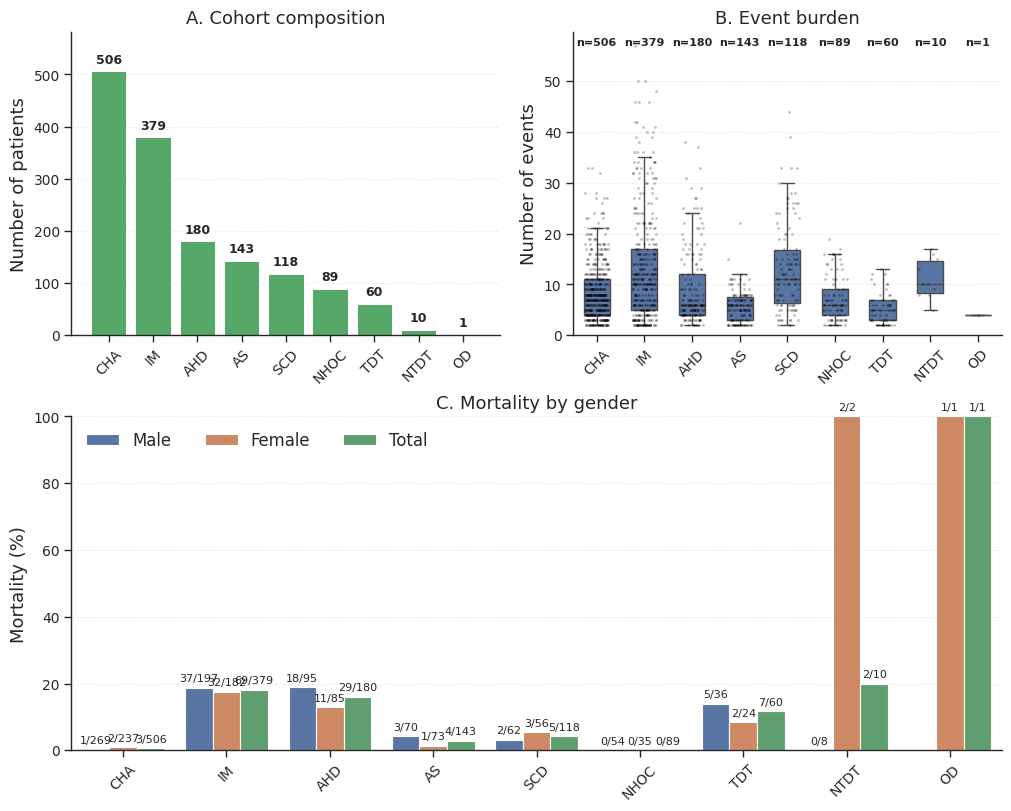

In [10]:
from scripts.plotting import plot_distribution, distrib_summary
disease_mapper = dict(zip(list(args.dataset["primary_disease"].unique()), disease_list))
fig = plot_distribution(args.dataset, disease_mapper)
distrib_summary(args.dataset, disease_mapper)

### count event by type and cardinality

In [11]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
surgical_operation,14,1561,"{Resection of adenoids, open approach, Transpl..."
therapy,39,4998,"{Introduction of acid-reducing agent, Introduc..."
vaccination,9,6548,"{Meningococcal conjugate vaccine, serogroups A..."
infection,71,555,"{Acute coronary syndrome (not infection), Acut..."
comorbidity,241,830,"{Osteomyelitis; Osteonecrosis - REVIEW, Pre-ex..."


## Get static variables

In [12]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,primary_disease
0,0,0,0
1,1,0,1
2,0,0,1
3,1,0,1
4,0,0,2
...,...,...,...
1784,1,0,1
1785,1,0,1
1786,1,2,1
1787,1,0,0


## Get targets

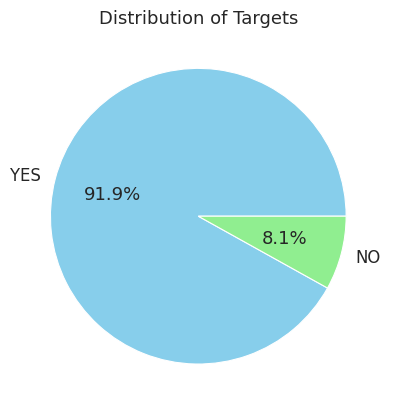

In [13]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(os.path.join(DATA_PATH, f"{dataset}_targets.csv"))
plt.show()

In [14]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, event_sequences_type, target_df.to_dict(), X_static, args)

# Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

## Validation (Iterated 5-fold)

In [15]:
import pickle
from scripts.cv_folding import lgbm_cv_iter
metrics = ["AUC","F1","Prec","Recall","MCC","Acc","Brier","CM"]
args.methods = [['STATIC'],
                ['STATIC', 'EVENT-CNT'], 
                ['STATIC', 'BiPadLSTM'], 
                ['STATIC', 'Med2Vec'],
                ['STATIC', 'Dipole'],
                ['STATIC', 'CEHR-BERT'],
                ['STATIC', 'DOME'],
                ['STATIC', 'GRU'],
                ]
prob_pred = {"+".join(m): [] for m in args.methods}
prob_true = {"+".join(m): [] for m in args.methods}
all_runs = {"+".join(m): ([], []) for m in args.methods}
res = {metric: {"+".join(m): [] for m in args.methods} for metric in metrics}
for i in range(args.iter):
    for m in args.methods:
        set_seed(args.random_state+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                            methods=m, threshold=thresh, random_state=args.random_state+i, 
                                                            return_metrics=True)
        prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
        prob_true["+".join(m)] += list(results['calibration_prob_true'])
        all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                    all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
        if args.save: 
            with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER{args.iter}.pkl", 'wb') as f:
                pickle.dump(results, f)
        for metric in res.keys():
            print("+".join(m), metric)
            res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv")
if args.save: results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER{args.iter}.csv")

STATIC+GRU AUC
STATIC+GRU F1
STATIC+GRU Prec
STATIC+GRU Recall
STATIC+GRU MCC
STATIC+GRU Acc
STATIC+GRU Brier
STATIC+GRU CM


## Radar plot and performance table

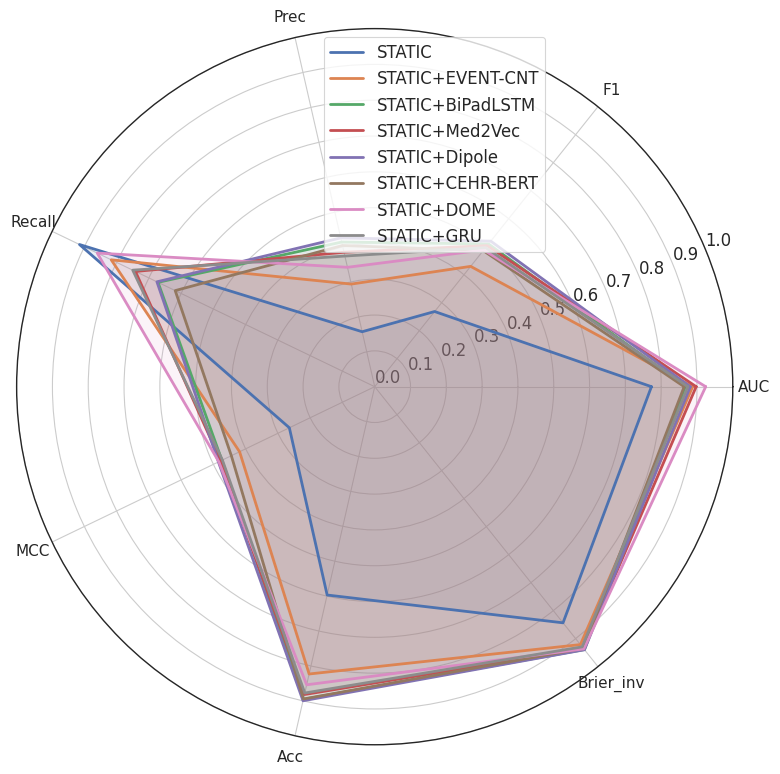

,AUC,F1,Prec,Recall,MCC,Acc,Brier,CM
Model,,,,,,,,
STATIC,0.773+0.034,0.268+0.014,0.157+0.009,0.915+0.053,0.265+0.026,0.597+0.026,0.156,"[[777.0, 589.0], [10.2, 109.8]]"
STATIC+EVENT-CNT,0.888+0.030,0.430+0.038,0.294+0.036,0.817+0.084,0.419+0.042,0.823+0.031,0.079,"[[1125.0, 241.0], [22.0, 98.0]]"
STATIC+BiPadLSTM,0.867+0.045,0.510+0.054,0.414+0.052,0.672+0.091,0.474+0.062,0.896+0.015,0.061,"[[1250.2, 115.8], [39.4, 80.6]]"
STATIC+Med2Vec,0.898+0.029,0.504+0.042,0.385+0.044,0.742+0.085,0.478+0.050,0.882+0.016,0.064,"[[1221.4, 144.6], [31.0, 89.0]]"
STATIC+Dipole,0.881+0.033,0.520+0.050,0.426+0.043,0.675+0.098,0.484+0.059,0.900+0.012,0.060,"[[1256.0, 110.0], [39.0, 81.0]]"
STATIC+CEHR-BERT,0.864+0.048,0.486+0.066,0.404+0.058,0.618+0.105,0.444+0.076,0.895+0.017,0.065,"[[1255.2, 110.8], [45.8, 74.2]]"
STATIC+DOME,0.924+0.025,0.488+0.033,0.342+0.029,0.860+0.066,0.483+0.039,0.854+0.016,0.063,"[[1165.8, 200.2], [16.8, 103.2]]"
STATIC+GRU,0.874+0.047,0.497+0.047,0.374+0.037,0.750+0.110,0.472+0.059,0.878+0.017,0.071,"[[1214.0, 152.0], [30.0, 90.0]]"


In [16]:
import pandas as pd
import numpy as np
from scripts.plotting import plot_radar

metrics = ["AUC", "F1", "Prec", "Recall", "MCC", "Acc",]
tmetrics = metrics + ['Brier', 'CM']
dfs = {}

for metric in tmetrics:
    dfs[metric] = pd.read_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv", index_col=0)
dfm = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfmp = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfm.index.name = "Model"
dfmp.index.name = "Model"
for method in dfs[metric].columns:
    values = []
    valuesp = []
    for metric in tmetrics:
        if metric == "CM":
            cm = dfs[metric][method].apply(lambda x: np.array(eval(x))).sum() / 5
            values += [cm]
            valuesp += [cm]
        elif metric == 'Brier':
            values += [1 - dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}"]
        else:
            values += [dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}+{dfs[metric][method].std():.3f}"]
    dfm.loc[method] = values
    dfmp.loc[method] = valuesp
dfm.rename(columns={"Brier": "Brier_inv"}, inplace=True)
fig = plot_radar(dfm, metrics + ['Brier_inv'])
dfmp

## Plot calibaration curves

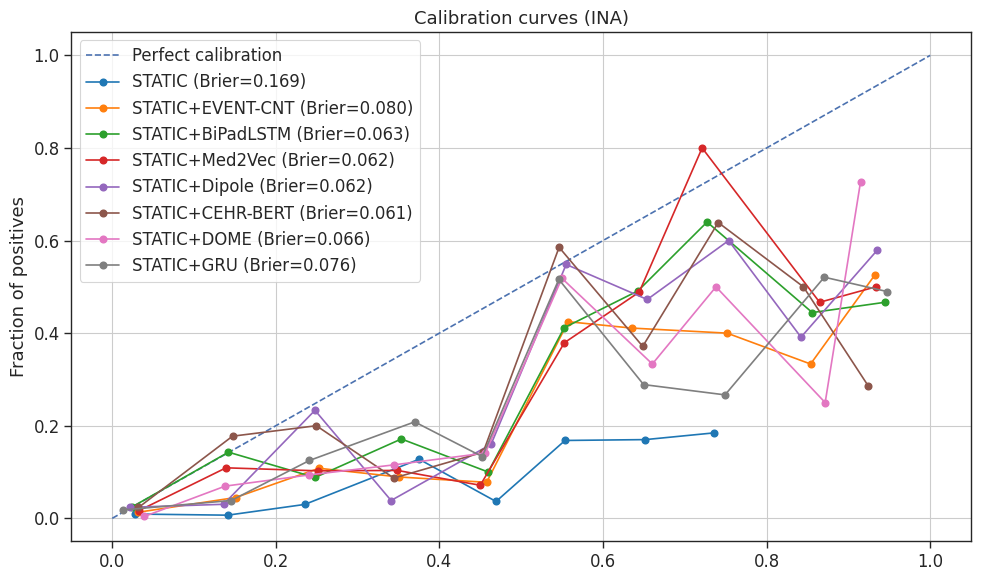

In [17]:
from scripts.plotting import plot_calibration
from scripts.utils import split_array
p_pred = {k:split_array(v)[0] for k,v in prob_pred.items()}
p_true = {k:list(v[0:len(p_pred[k])]) for k,v in prob_true.items()}
a_runs = {k:(v[0][0:1486], v[1][0:1486]) for k,v in all_runs.items()}
fig = plot_calibration(p_pred, p_true, a_runs,title=f"Calibration curves ({dataset})")